## 1. Imports & chargement des données

In [94]:
import sys
sys.path.append("../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

players = pd.read_parquet("../../data/processed/player_hands.parquet")
hands   = pd.read_parquet("../../data/processed/hands.parquet")
actions = pd.read_parquet("../../data/processed/actions.parquet")

print(f"player_hands : {players.shape}")
print(f"hands        : {hands.shape}")
print(f"actions      : {actions.shape}")

player_hands : (6840826, 24)
hands        : (1272315, 18)
actions      : (14130075, 6)


In [95]:
# Micro-stakes : big blind <= $1
hands_under_one          = hands.loc[hands["big_blind"] <= 1].copy()
player_hands_under_one   = players.loc[players["game_id"].isin(hands_under_one["game_id"])].copy()
actions_under_one        = actions.loc[actions["game_id"].isin(hands_under_one["game_id"])].copy()

print(hands_under_one.shape, player_hands_under_one.shape, actions_under_one.shape)

(714469, 18) (4068979, 24) (8286488, 6)


## 2. Feature Engineering par joueur

On agrège les stats par joueur pour construire un vecteur de features représentant son style de jeu :

| Feature | Description | Profil indicatif |
|---|---|---|
| `vpip_rate` | % mains où le joueur entre volontairement dans le pot | élevé → loose |
| `pfr_rate` | % mains avec relance preflop | élevé → agressif |
| `3bet_rate` | % mains avec 3-bet preflop | élevé → très agressif |
| `aggression_factor` | (bets+raises postflop) / calls postflop | élevé → agressif postflop |
| `flop_rate` | % mains voyant le flop | corrélé VPIP |
| `wtsd_rate` | % mains allant au showdown | élevé → calling station |
| `wsd_rate` | % showdowns gagnés | élevé → bonnes mains au showdown |

In [96]:
# ── 2.1 Agrégation de base depuis player_hands ──────────────────────────────
agg = (
    player_hands_under_one
    .groupby("player")
    .agg(
        n_hands          = ("game_id",       "count"),
        vpip_rate        = ("vpip",           "mean"),
        pfr_rate         = ("preflop_raise",  "mean"),
        flop_rate        = ("saw_flop",       "mean"),
        wtsd_rate        = ("showdown",       "mean"),
        won_hand_rate    = ("won_hand",        "mean"),
        avg_net_result   = ("net_result",      "mean"),
        total_net_result = ("net_result",      "sum"),
        avg_stack        = ("stack_start",     "mean"),
    )
    .reset_index()
)

# ── 2.2 WSD rate : % showdowns gagnés (parmi les mains avec showdown) ───────
wsd = (
    player_hands_under_one.loc[player_hands_under_one["showdown"] == 1]
    .groupby("player")["won_hand"]
    .mean()
    .rename("wsd_rate")
    .reset_index()
)
agg = agg.merge(wsd, on="player", how="left")
agg["wsd_rate"] = agg["wsd_rate"].fillna(0)

# ── 2.3 Stack normalisé en BB ────────────────────────────────────────────────
bb_per_game = hands_under_one[["game_id", "big_blind"]].drop_duplicates()
ph_bb = player_hands_under_one.merge(bb_per_game, on="game_id", how="left")
ph_bb["stack_in_bb"] = ph_bb["stack_start"] / ph_bb["big_blind"]
stack_bb = ph_bb.groupby("player")["stack_in_bb"].mean().rename("avg_stack_bb").reset_index()
agg = agg.merge(stack_bb, on="player", how="left")

print(f"Joueurs uniques : {len(agg)}")
agg.head()

Joueurs uniques : 18536


,player,n_hands,vpip_rate,pfr_rate,flop_rate,wtsd_rate,won_hand_rate,avg_net_result,total_net_result,avg_stack,wsd_rate,avg_stack_bb
0,++GkYwc9uSlxEx8lsNRJ6A,36,0.389,0.000,0.444,0.278,0.250,0.332,11.950,20.242,0.900,40.483
1,++HNtoYfMEJQDBuUlgpmXw,41,0.512,0.024,0.439,0.073,0.073,-1.266,-51.910,50.690,1.000,59.487
2,++OJ33zjV02/PZlX7Tlz7w,69,0.725,0.333,0.594,0.377,0.333,0.753,51.970,53.186,0.885,56.569
3,++ZiLZDZQ+0Fp0aS/6ZQMQ,27,0.407,0.148,0.259,0.333,0.296,-0.113,-3.050,77.643,0.889,77.643
4,++ZtL8fqfhxBUDpfZmjT4g,4,1.000,0.000,0.750,0.250,0.250,-0.275,-1.100,44.013,1.000,88.025


In [97]:
# ── 2.4 Aggression Factor (postflop) ────────────────────────────────────────
# AF = (bets + raises postflop) / (calls postflop + 1)
postflop = actions_under_one.loc[
    actions_under_one["street"].isin(["flop", "turn", "river"])
]
af_raw = (
    postflop
    .groupby(["player", "action_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["bet", "raise", "call"]:
    if col not in af_raw.columns:
        af_raw[col] = 0
af_raw["aggression_factor"] = (af_raw["bet"] + af_raw["raise"]) / (af_raw["call"] + 1)
agg = agg.merge(af_raw[["player", "aggression_factor"]], on="player", how="left")
agg["aggression_factor"] = agg["aggression_factor"].fillna(0)

# ── 2.5 3-Bet rate preflop ──────────────────────────────────────────────────
# Un 3-bet est la 2ème relance dans la même main preflop
preflop_raises = (
    actions_under_one
    .loc[
        (actions_under_one["street"] == "preflop") &
        (actions_under_one["action_type"] == "raise")
    ]
    .copy()
)
preflop_raises["raise_order"] = preflop_raises.groupby("game_id").cumcount() + 1
threebets = (
    preflop_raises.loc[preflop_raises["raise_order"] == 2, "player"]
    .value_counts()
    .rename("n_3bet")
    .reset_index()
)
agg = agg.merge(threebets, on="player", how="left")
agg["n_3bet"] = agg["n_3bet"].fillna(0)
agg["threebet_rate"] = agg["n_3bet"] / agg["n_hands"]

print(f"Features disponibles : {list(agg.columns)}")
agg.describe()

Features disponibles : ['player', 'n_hands', 'vpip_rate', 'pfr_rate', 'flop_rate', 'wtsd_rate', 'won_hand_rate', 'avg_net_result', 'total_net_result', 'avg_stack', 'wsd_rate', 'avg_stack_bb', 'aggression_factor', 'n_3bet', 'threebet_rate']


,n_hands,vpip_rate,pfr_rate,flop_rate,wtsd_rate,won_hand_rate,avg_net_result,total_net_result,avg_stack,wsd_rate,avg_stack_bb,aggression_factor,n_3bet,threebet_rate
count,18536.000,18536.000,18536.000,18536.000,18536.000,18536.000,18536.000,18536.000,18533.000,18536.000,18533.000,18536.000,18536.000,18536.000
mean,219.518,0.380,0.108,0.377,0.249,0.203,0.099,57.301,55.335,0.800,78.922,2.051,2.223,0.011
std,691.711,0.180,0.113,0.173,0.160,0.136,2.562,266.691,46.943,0.250,54.055,3.559,9.434,0.037
min,1.000,0.000,0.000,0.000,0.000,0.000,-99.000,-1005.960,1.549,0.000,3.097,0.000,0.000,0.000
25%,21.000,0.254,0.032,0.258,0.147,0.119,-0.320,-12.850,23.930,0.773,41.650,1.000,0.000,0.000
50%,60.000,0.360,0.082,0.354,0.216,0.178,0.054,2.955,40.000,0.875,60.274,1.667,0.000,0.000
75%,161.000,0.491,0.147,0.475,0.315,0.256,0.499,50.625,68.630,0.945,99.043,2.600,1.000,0.011
max,26503.000,1.000,1.000,1.000,1.000,1.000,98.500,10486.580,748.359,1.000,748.359,302.900,459.000,1.000


## 3. Exploration des features

Joueurs avec >= 500 mains : 1615 / 18536


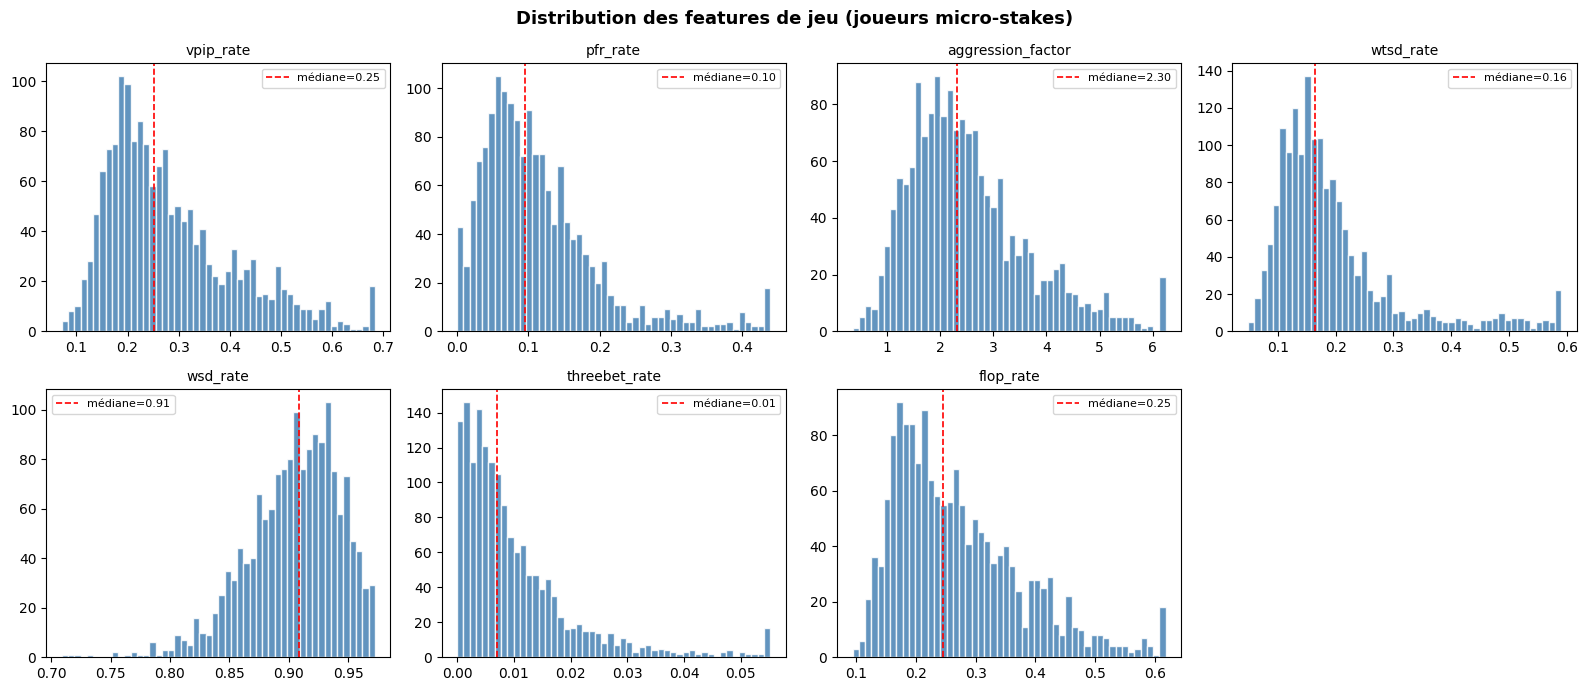

In [123]:
# Filtrer les joueurs avec suffisamment de mains (fiabilité statistique)
MIN_HANDS = 500
agg_filtered = agg.loc[agg["n_hands"] >= MIN_HANDS].copy()
print(f"Joueurs avec >= {MIN_HANDS} mains : {len(agg_filtered)} / {len(agg)}")

FEATURES = ["vpip_rate", "pfr_rate", "aggression_factor", "wtsd_rate", "wsd_rate", "threebet_rate", "flop_rate"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Distribution des features de jeu (joueurs micro-stakes)", fontsize=13, fontweight="bold")

for ax, feat in zip(axes.flatten(), FEATURES):
    data = agg_filtered[feat].clip(upper=agg_filtered[feat].quantile(0.99))
    ax.hist(data, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.axvline(data.median(), color="red", linestyle="--", lw=1.2, label=f"médiane={data.median():.2f}")
    ax.legend(fontsize=8)

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

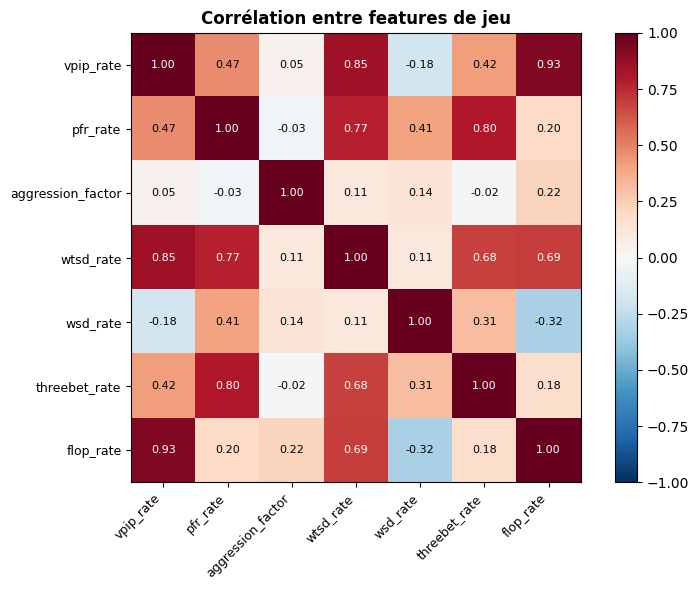

In [124]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(8, 6))
corr = agg_filtered[FEATURES].corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(FEATURES, fontsize=9)

for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

ax.set_title("Corrélation entre features de jeu", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Clustering K-Means

On normalise les features puis on cherche le nombre optimal de clusters via :
- la méthode du coude (inertie)
- le score de silhouette

In [125]:
# Préparation : normalisation
X = agg_filtered[FEATURES].copy()

# Cap des valeurs extrêmes (99e percentile)
for col in FEATURES:
    cap = X[col].quantile(0.99)
    X[col] = X[col].clip(upper=cap)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matrice d'entrée : {X_scaled.shape}")

Matrice d'entrée : (1615, 7)


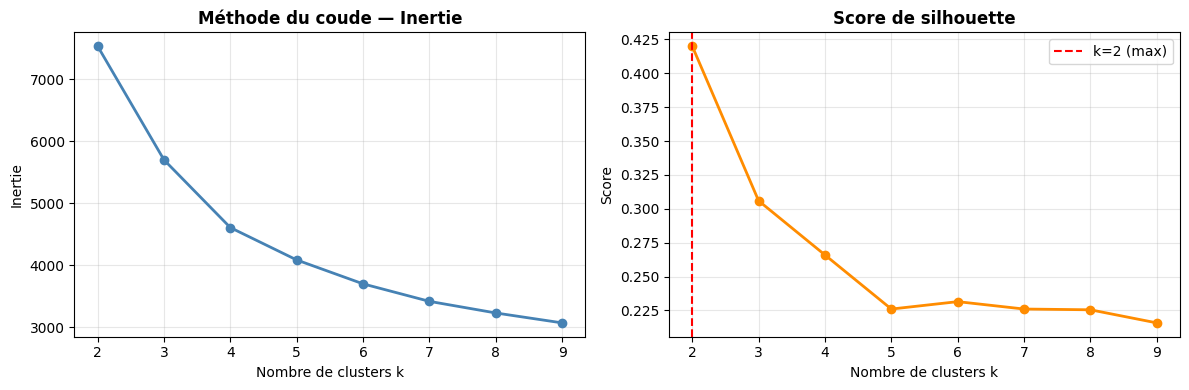

Meilleur k selon silhouette : 2  (score=0.420)


In [126]:
# ── Méthode du coude ────────────────────────────────────────────────────────
K_RANGE = range(2, 10)
inertias = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertias, "o-", color="steelblue", linewidth=2)
ax1.set_title("Méthode du coude — Inertie", fontweight="bold")
ax1.set_xlabel("Nombre de clusters k")
ax1.set_ylabel("Inertie")
ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), sil_scores, "o-", color="darkorange", linewidth=2)
ax2.set_title("Score de silhouette", fontweight="bold")
ax2.set_xlabel("Nombre de clusters k")
ax2.set_ylabel("Score")
ax2.grid(alpha=0.3)

best_k = list(K_RANGE)[np.argmax(sil_scores)]
ax2.axvline(best_k, color="red", linestyle="--", label=f"k={best_k} (max)")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"Meilleur k selon silhouette : {best_k}  (score={max(sil_scores):.3f})")

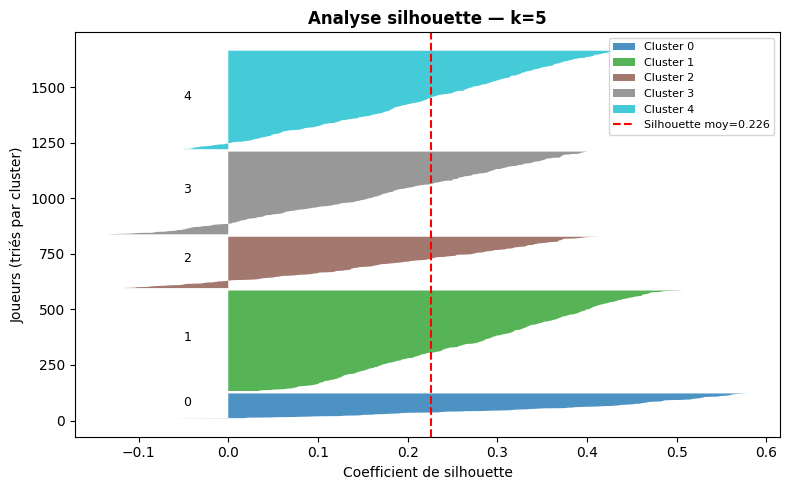

In [127]:
# ── Silhouette plot détaillé pour k optimal ──────────────────────────────────
K_FINAL = 5  # peut être ajusté manuellement si besoin

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

sil_vals = silhouette_samples(X_scaled, cluster_labels)
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, K_FINAL))

for i in range(K_FINAL):
    vals_i = np.sort(sil_vals[cluster_labels == i])
    size_i = vals_i.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                     facecolor=colors[i], alpha=0.8, label=f"Cluster {i}")
    ax.text(-0.05, y_lower + size_i / 2, str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(silhouette_score(X_scaled, cluster_labels), color="red",
           linestyle="--", label=f"Silhouette moy={silhouette_score(X_scaled, cluster_labels):.3f}")
ax.set_title(f"Analyse silhouette — k={K_FINAL}", fontweight="bold")
ax.set_xlabel("Coefficient de silhouette")
ax.set_ylabel("Joueurs (triés par cluster)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [128]:
# ── Labellisation des clusters ───────────────────────────────────────────────
agg_filtered = agg_filtered.copy()
agg_filtered["cluster"] = cluster_labels

# Profil moyen par cluster
profile = (
    agg_filtered
    .groupby("cluster")[FEATURES + ["avg_net_result", "n_hands"]]
    .mean()
    .round(3)
)
profile["n_players"] = agg_filtered.groupby("cluster").size()
print(profile.to_string())

# ── Règles de labellisation ──────────────────────────────────────────────────
# TAG  : VPIP bas + PFR élevé  → tight agressif
# LAG  : VPIP élevé + PFR élevé → loose agressif
# Nit  : VPIP très bas + PFR bas → ultra serré
# Fish : VPIP élevé + PFR bas   → passif, calling station
# Maniac (si k>=5) : VPIP très élevé + PFR très élevé + AF extrême

def label_cluster(row):
    vpip = row["vpip_rate"]
    pfr  = row["pfr_rate"]
    af   = row["aggression_factor"]
    if vpip < 0.15 and pfr < 0.10:
        return "Nit"
    elif vpip >= 0.40 and pfr >= 0.30 and af >= 2.0:
        return "Maniac"
    elif vpip >= 0.35 and pfr < 0.20:
        return "Fish"
    elif vpip >= 0.28 and pfr >= 0.22:
        return "LAG"
    else:
        return "TAG"

cluster_labels_map = profile.apply(label_cluster, axis=1).to_dict()
agg_filtered["profile"] = agg_filtered["cluster"].map(cluster_labels_map)

print("\nMapping clusters → profils :")
print(cluster_labels_map)
print("\nDistribution des profils :")
print(agg_filtered["profile"].value_counts())

         vpip_rate  pfr_rate  aggression_factor  wtsd_rate  wsd_rate  threebet_rate  flop_rate  avg_net_result  n_hands  n_players
cluster                                                                                                                           
0            0.508     0.344              2.646      0.502     0.938          0.039      0.393           0.837 1125.434        113
1            0.182     0.074              2.399      0.119     0.920          0.005      0.191           0.160 2090.433        453
2            0.470     0.119              4.989      0.288     0.876          0.010      0.452           0.404  839.483        232
3            0.230     0.153              3.772      0.181     0.930          0.015      0.204           0.285 2165.759        373
4            0.277     0.063              1.813      0.162     0.872          0.005      0.286           0.220 1045.989        444

Mapping clusters → profils :
{0: 'Maniac', 1: 'TAG', 2: 'Fish', 3: 'TAG', 4: 'TAG'

## 5. Visualisation des clusters

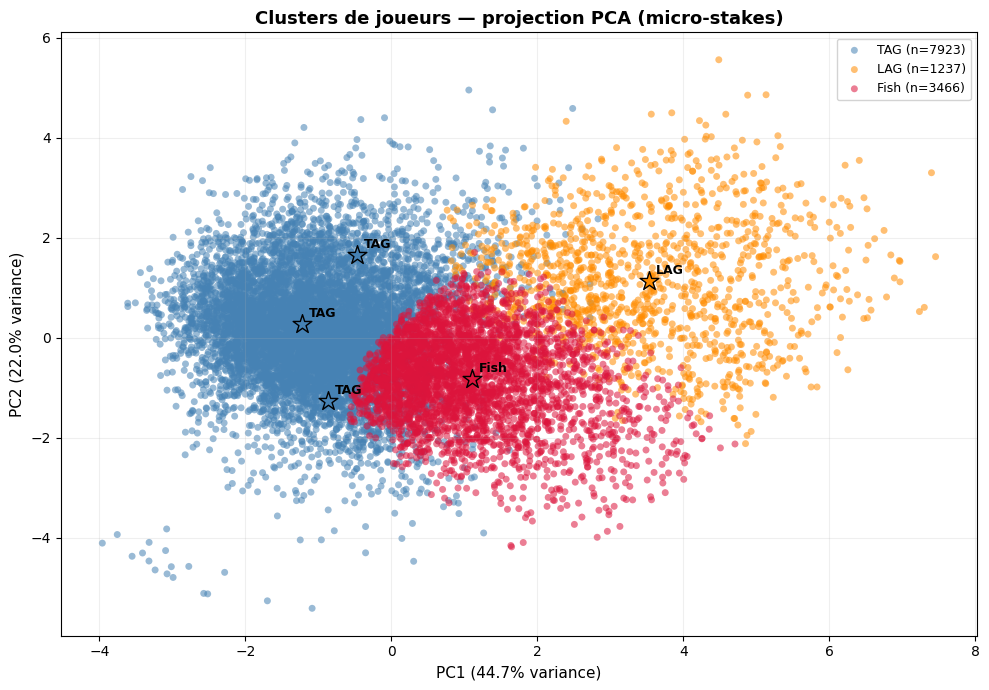

Variance expliquée PC1+PC2 : 66.7%


In [104]:
# ── PCA 2D ───────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

PROFILE_COLORS = {
    "TAG":    "steelblue",
    "LAG":    "darkorange",
    "Nit":    "forestgreen",
    "Fish":   "crimson",
    "Maniac": "purple",
}

fig, ax = plt.subplots(figsize=(10, 7))
for profile_name, color in PROFILE_COLORS.items():
    mask = agg_filtered["profile"] == profile_name
    if mask.sum() == 0:
        continue
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f"{profile_name} (n={mask.sum()})",
        color=color, alpha=0.55, s=25, edgecolors="none"
    )

# Centroïdes
centers_pca = pca.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centers_pca):
    profile_name = cluster_labels_map[i]
    ax.scatter(cx, cy, s=200, marker="*",
               color=PROFILE_COLORS.get(profile_name, "black"), edgecolors="black", zorder=5)
    ax.annotate(profile_name, (cx, cy), fontsize=9, fontweight="bold",
                xytext=(5, 5), textcoords="offset points")

var_explained = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} variance)", fontsize=11)
ax.set_title("Clusters de joueurs — projection PCA (micro-stakes)", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.85, fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Variance expliquée PC1+PC2 : {sum(var_explained):.1%}")

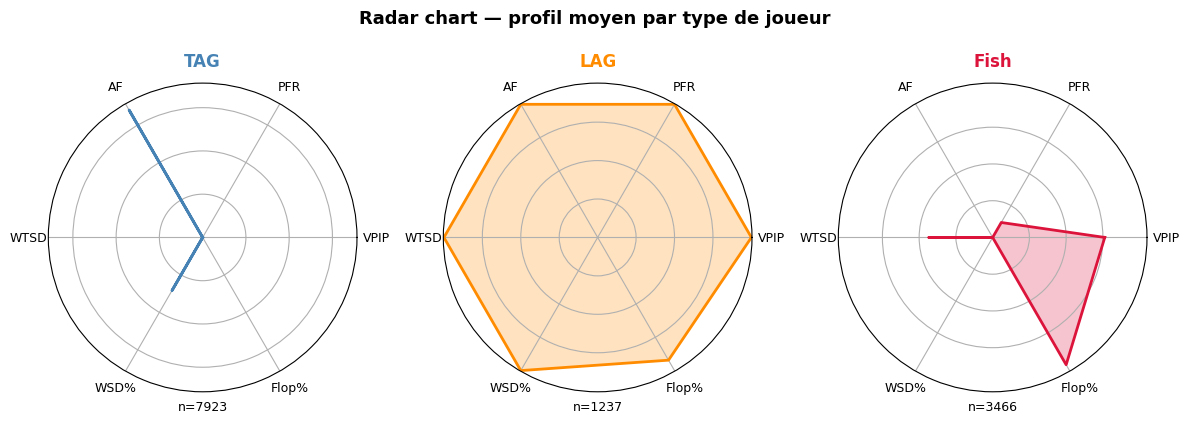

In [105]:
# ── Radar chart par profil ───────────────────────────────────────────────────
RADAR_FEATURES = ["vpip_rate", "pfr_rate", "aggression_factor", "wtsd_rate", "wsd_rate", "flop_rate"]
RADAR_LABELS   = ["VPIP", "PFR", "AF", "WTSD", "WSD%", "Flop%"]
N = len(RADAR_FEATURES)

# Normaliser entre 0 et 1 pour le radar (min-max sur les moyennes de clusters)
cluster_means = agg_filtered.groupby("profile")[RADAR_FEATURES].mean()
radar_data = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermer le polygone

profiles_to_plot = [p for p in ["Nit", "TAG", "LAG", "Fish", "Maniac"] if p in radar_data.index]
fig, axes = plt.subplots(1, len(profiles_to_plot), figsize=(4 * len(profiles_to_plot), 4),
                          subplot_kw=dict(polar=True))
if len(profiles_to_plot) == 1:
    axes = [axes]
fig.suptitle("Radar chart — profil moyen par type de joueur", fontsize=13, fontweight="bold", y=1.02)

for ax, prof in zip(axes, profiles_to_plot):
    values = radar_data.loc[prof].tolist() + radar_data.loc[prof].tolist()[:1]
    color = PROFILE_COLORS.get(prof, "gray")
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=9)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels([])
    ax.set_title(prof, fontsize=12, fontweight="bold", color=color, pad=12)
    n_pl = (agg_filtered["profile"] == prof).sum()
    ax.set_xlabel(f"n={n_pl}", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Analyse de la rentabilité par profil

> **Enjeu business clé** : le profil détermine-t-il les gains ? Un TAG devrait gagner, un Fish perdre.

In [106]:
# ── Statistiques de gains par profil ────────────────────────────────────────
profit_stats = (
    agg_filtered
    .groupby("profile")
    .agg(
        n_players         = ("player",          "count"),
        avg_net_per_hand  = ("avg_net_result",   "mean"),
        median_net        = ("avg_net_result",   "median"),
        std_net           = ("avg_net_result",   "std"),
        pct_winners       = ("avg_net_result",   lambda x: (x > 0).mean()),
        total_net         = ("total_net_result", "sum"),
    )
    .sort_values("avg_net_per_hand", ascending=False)
    .round(3)
)

print("=" * 70)
print("RENTABILITÉ MOYENNE PAR PROFIL")
print("=" * 70)
print(profit_stats.to_string())

RENTABILITÉ MOYENNE PAR PROFIL
         n_players  avg_net_per_hand  median_net  std_net  pct_winners  total_net
profile                                                                          
LAG           1237             0.653       0.411    1.637        0.697 193599.990
Fish          3466             0.383       0.212    1.096        0.645 217780.240
TAG           7923             0.179       0.089    0.799        0.611 650132.560


C:\Users\mael.zpt\AppData\Local\Temp\ipykernel_26704\1088585372.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_by_profile, labels=order, patch_artist=True, notch=False,


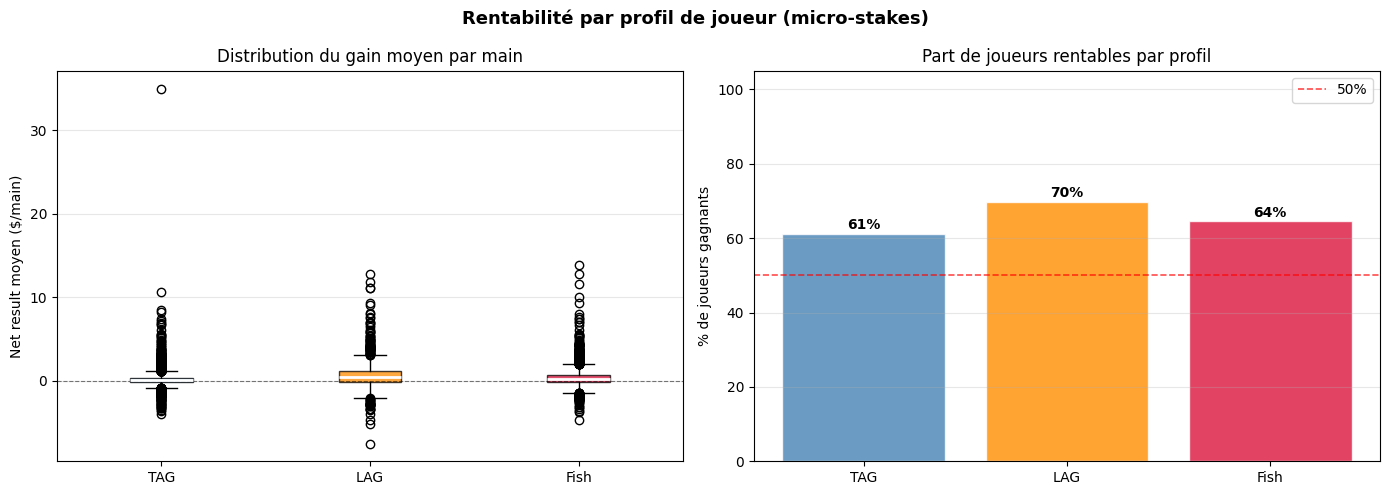

In [107]:
# ── Box plots : distribution des gains ──────────────────────────────────────
order = ["Nit", "TAG", "LAG", "Fish", "Maniac"]
order = [p for p in order if p in agg_filtered["profile"].unique()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Rentabilité par profil de joueur (micro-stakes)", fontsize=13, fontweight="bold")

# Box plot du net result moyen par main
data_by_profile = [agg_filtered.loc[agg_filtered["profile"] == p, "avg_net_result"] for p in order]
bp = ax1.boxplot(data_by_profile, labels=order, patch_artist=True, notch=False,
                 medianprops=dict(color="white", linewidth=2))
for patch, prof in zip(bp["boxes"], order):
    patch.set_facecolor(PROFILE_COLORS.get(prof, "gray"))
    patch.set_alpha(0.75)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax1.set_ylabel("Net result moyen ($/main)")
ax1.set_title("Distribution du gain moyen par main")
ax1.grid(axis="y", alpha=0.3)

# % de joueurs gagnants
win_rates = [profit_stats.loc[p, "pct_winners"] * 100 if p in profit_stats.index else 0 for p in order]
colors_bar = [PROFILE_COLORS.get(p, "gray") for p in order]
bars = ax2.bar(order, win_rates, color=colors_bar, alpha=0.8, edgecolor="white")
ax2.axhline(50, color="red", linewidth=1.2, linestyle="--", alpha=0.7, label="50%")
for bar, val in zip(bars, win_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("% de joueurs gagnants")
ax2.set_title("Part de joueurs rentables par profil")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

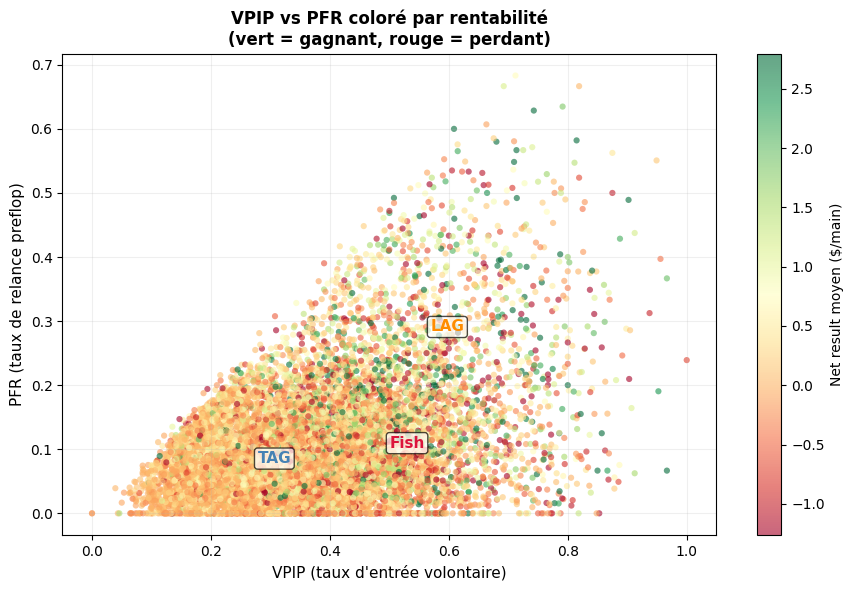

In [108]:
# ── VPIP vs PFR : scatter coloré par gain moyen ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

net_clip = agg_filtered["avg_net_result"].clip(
    agg_filtered["avg_net_result"].quantile(0.02),
    agg_filtered["avg_net_result"].quantile(0.98)
)
sc = ax.scatter(
    agg_filtered["vpip_rate"],
    agg_filtered["pfr_rate"],
    c=net_clip, cmap="RdYlGn", alpha=0.6, s=20, edgecolors="none"
)
plt.colorbar(sc, ax=ax, label="Net result moyen ($/main)")

# Annotations des centroïdes
for prof in agg_filtered["profile"].unique():
    sub = agg_filtered.loc[agg_filtered["profile"] == prof]
    ax.annotate(prof,
                xy=(sub["vpip_rate"].mean(), sub["pfr_rate"].mean()),
                fontsize=11, fontweight="bold",
                color=PROFILE_COLORS.get(prof, "black"),
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.set_xlabel("VPIP (taux d'entrée volontaire)", fontsize=11)
ax.set_ylabel("PFR (taux de relance preflop)", fontsize=11)
ax.set_title("VPIP vs PFR coloré par rentabilité\n(vert = gagnant, rouge = perdant)",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Synthèse Business

### Tableau de bord des profils

In [109]:
# ── Tableau récapitulatif complet ────────────────────────────────────────────
summary = (
    agg_filtered
    .groupby("profile")
    .agg(
        n_joueurs        = ("player",          "count"),
        VPIP             = ("vpip_rate",        "mean"),
        PFR              = ("pfr_rate",         "mean"),
        AF               = ("aggression_factor","mean"),
        WTSD             = ("wtsd_rate",        "mean"),
        WSD_pct          = ("wsd_rate",         "mean"),
        gain_moyen       = ("avg_net_result",   "mean"),
        pct_gagnants     = ("avg_net_result",   lambda x: (x > 0).mean()),
    )
    .sort_values("gain_moyen", ascending=False)
)

summary["VPIP"]       = (summary["VPIP"]       * 100).round(1).astype(str) + "%"
summary["PFR"]        = (summary["PFR"]        * 100).round(1).astype(str) + "%"
summary["WTSD"]       = (summary["WTSD"]       * 100).round(1).astype(str) + "%"
summary["WSD_pct"]    = (summary["WSD_pct"]    * 100).round(1).astype(str) + "%"
summary["pct_gagnants"] = (summary["pct_gagnants"] * 100).round(1).astype(str) + "%"
summary["AF"]         = summary["AF"].round(2)
summary["gain_moyen"] = summary["gain_moyen"].round(3)

print("\n" + "=" * 85)
print("PROFILS DE JOUEURS — SYNTHÈSE (micro-stakes, BB ≤ $1)")
print("=" * 85)
print(summary.to_string())


PROFILS DE JOUEURS — SYNTHÈSE (micro-stakes, BB ≤ $1)
         n_joueurs   VPIP    PFR    AF   WTSD WSD_pct  gain_moyen pct_gagnants
profile                                                                       
LAG           1237  56.9%  28.4% 2.640  47.3%   88.8%       0.653        69.7%
Fish          3466  50.0%  10.3% 1.850  30.2%   86.0%       0.383        64.5%
TAG           7923  27.8%   7.8% 2.520  17.0%   87.0%       0.179        61.1%


### Interprétation et recommandations business

#### Profils identifiés

| Profil | Caractéristique | Tendance gain | Représente |
|--------|----------------|--------------|------------|
| **TAG** | VPIP faible, PFR élevé, AF élevé | ✅ Gagnant | Joueur solide, sélectif et agressif |
| **LAG** | VPIP élevé, PFR élevé, AF très élevé | ✅ Gagnant (risqué) | Expert exploitant les faiblesses adverses |
| **Nit** | VPIP très faible, joue peu | ⚖️ Neutre/légèrement gagnant | Ultra-sélectif, difficile à exploiter |
| **Fish** | VPIP élevé, PFR bas, WTSD élevé | ❌ Perdant | Joueur récréatif, calling station |
| **Maniac** | Tout élevé, AF extrême | ❌ Très variable | Joueur imprévisible / potentiellement bot |

#### Applications business

1. **Recommandation de table** : Identifier des tables avec plusieurs Fish pour y guider les TAGs → augmentation du rake payé par les gagnants réguliers

2. **Détection de bots** : Les bots ont des stats mécaniques très serrées (VPIP/PFR quasi fixes, AF parfaitement constant). Un cluster avec variance anormalement basse mérite une investigation.

3. **Coaching personnalisé** : Une app de poker peut détecter automatiquement le profil d'un élève et lui proposer des modules ciblés (ex: un Fish → leçons sur la sélection de mains preflop).

4. **Rétention des Fish** : Les Fish sont la principale source de rake pour les plateformes. Les identifier permet de leur proposer des bonus ciblés pour prolonger leur activité.

5. **Alerte dynamique** : Si un joueur habituellement TAG commence à jouer comme un Fish (VPIP monte, PFR baisse), il peut être en tilt → alerte de jeu responsable.